In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/time_series_dataset- Activity 1.csv')

# Display the first 5 rows and information about the dataframe
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             168 non-null    object 
 1   visitors              168 non-null    int64  
 2   page_views            168 non-null    int64  
 3   bounce_rate           168 non-null    float64
 4   avg_session_duration  168 non-null    int64  
 5   server_load           168 non-null    float64
 6   temperature           168 non-null    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 9.3+ KB
None


,timestamp,visitors,page_views,bounce_rate,avg_session_duration,server_load,temperature
0,2025-01-01 00:00:00,226,531,0.35,166,0.49,21.1
1,2025-01-01 01:00:00,275,156,0.55,186,0.21,26.3
2,2025-01-01 02:00:00,428,1286,0.43,391,0.53,25.2
3,2025-01-01 03:00:00,354,837,0.33,324,0.69,21.8
4,2025-01-01 04:00:00,120,644,0.32,300,0.50,24.1


In [5]:
# Convert 'timestamp' to datetime and set as index
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2025-01-01 00:00:00 to 2025-01-07 23:00:00
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visitors              168 non-null    int64  
 1   page_views            168 non-null    int64  
 2   bounce_rate           168 non-null    float64
 3   avg_session_duration  168 non-null    int64  
 4   server_load           168 non-null    float64
 5   temperature           168 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 9.2 KB
None


,visitors,page_views,bounce_rate,avg_session_duration,server_load,temperature
timestamp,,,,,,
2025-01-01 00:00:00,226,531,0.35,166,0.49,21.1
2025-01-01 01:00:00,275,156,0.55,186,0.21,26.3
2025-01-01 02:00:00,428,1286,0.43,391,0.53,25.2
2025-01-01 03:00:00,354,837,0.33,324,0.69,21.8
2025-01-01 04:00:00,120,644,0.32,300,0.50,24.1


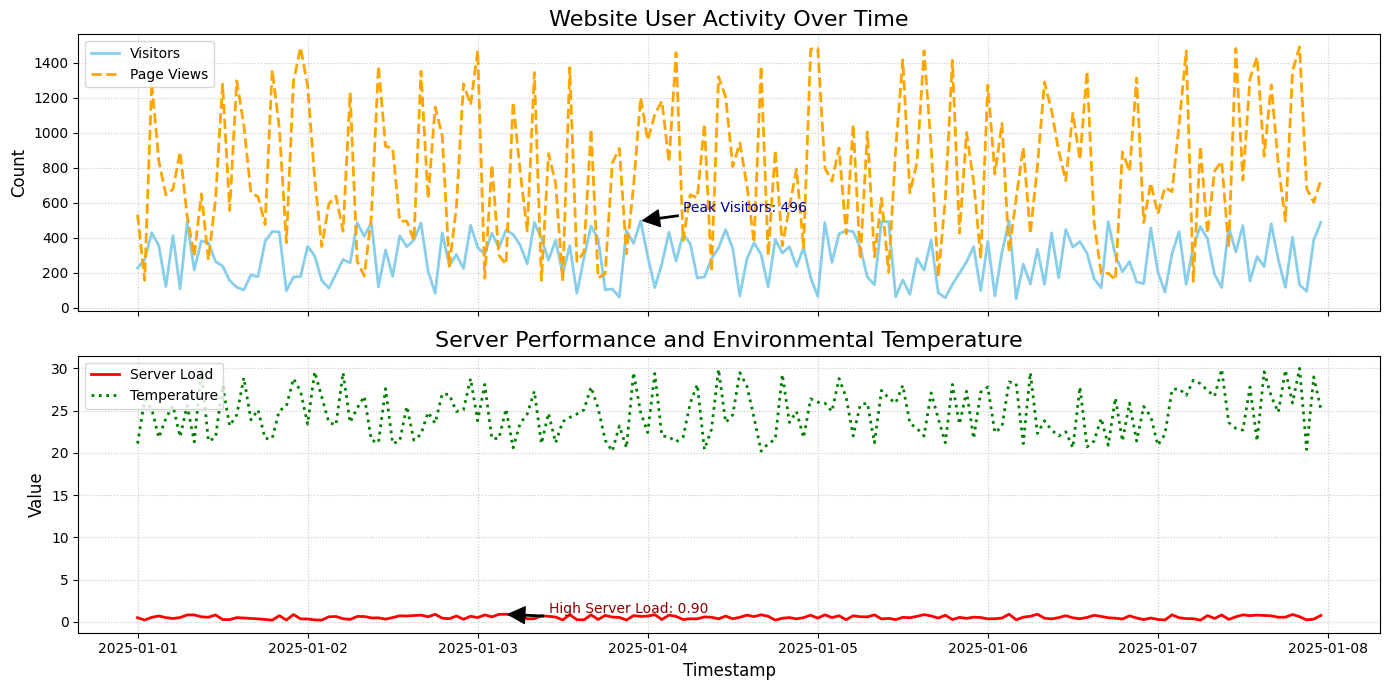

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 7), sharex=True) # Reduced figsize for a shorter plot

# Subplot 1: User Activity (Visitors and Page Views) with Seaborn
sns.lineplot(x=df.index, y='visitors', data=df, ax=axes[0], label='Visitors', color='skyblue', linewidth=2)
sns.lineplot(x=df.index, y='page_views', data=df, ax=axes[0], label='Page Views', color='orange', linestyle='--', linewidth=2)
axes[0].set_title('Website User Activity Over Time', fontsize=16)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Annotate peak visitor activity (remains the same)
peak_visitors_time = df['visitors'].idxmax()
peak_visitors_value = df['visitors'].max()
axes[0].annotate(f'Peak Visitors: {peak_visitors_value}',
             xy=(peak_visitors_time, peak_visitors_value),
             xytext=(peak_visitors_time + pd.Timedelta(hours=6), peak_visitors_value + 50),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, color='darkblue')

# Subplot 2: Server Load and Temperature with Seaborn
sns.lineplot(x=df.index, y='server_load', data=df, ax=axes[1], label='Server Load', color='red', linewidth=2)
sns.lineplot(x=df.index, y='temperature', data=df, ax=axes[1], label='Temperature', color='green', linestyle=':', linewidth=2)
axes[1].set_title('Server Performance and Environmental Temperature', fontsize=16)
axes[1].set_xlabel('Timestamp', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.7)

# Annotate high server load (remains the same)
peak_server_load_time = df['server_load'].idxmax()
peak_server_load_value = df['server_load'].max()
axes[1].annotate(f'High Server Load: {peak_server_load_value:.2f}',
             xy=(peak_server_load_time, peak_server_load_value),
             xytext=(peak_server_load_time + pd.Timedelta(hours=6), peak_server_load_value + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, color='darkred')

plt.tight_layout()
plt.show()